# Chapter 3: Symbolic Regression -- Discovering Physics from Data

In this notebook, we apply **Symbolic Regression (SR)** to a classic structural engineering problem: predicting the **tip deflection of a cantilever beam** under a point load. Unlike linear regression (Chapter 2), SR doesn't assume a model form in advance. Instead, it uses **Genetic Programming (GP)** to *evolve* mathematical expressions that best fit the data.

---

## 1. Imports

We need:
- **NumPy** and **Pandas** for data handling
- **Matplotlib** for plotting
- **SymPy** for symbolic math (interpreting discovered expressions)
- **gplearn** for Genetic Programming-based Symbolic Regression

In [ ]:
!pip install gplearn

import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt
from gplearn.genetic import SymbolicRegressor
from gplearn.fitness import make_fitness
from gplearn.functions import _Function

%matplotlib inline

print("All imports successful!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 36.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
All imports successful!


## 2. Physics Background: Cantilever Beam Deflection

### The Problem

A **cantilever beam** is a beam fixed at one end and free at the other. When a point load $P$ is applied at the free end, the beam deflects.

From **Euler-Bernoulli beam theory**, the maximum tip deflection $\delta$ is:

$$\delta = \frac{P \cdot L^3}{3 \cdot E \cdot I}$$

where:
- $P$ = applied load (N)
- $L$ = beam length (m)
- $E$ = Young's modulus (Pa)
- $I$ = second moment of area (m⁴)

### Our Goal

We will **not** tell the algorithm this formula. Instead, we'll provide it with $(P, L, \delta)$ data and let Symbolic Regression **rediscover** the functional relationship $\delta = k \cdot P \cdot L^3$ (where $k = \frac{1}{3EI}$ is a constant).

### Beam Cross-Section

We use a **hollow rectangular section** (common in structural steel):
- Outer height $h = 100$ mm
- Outer width $b = 50$ mm
- Wall thickness $t = 4$ mm
- Steel: $E = 210$ GPa

## 3. Data Generation

We generate **400 synthetic samples** with:
- Load $P \in [500, 5000]$ N (uniform random)
- Length $L \in [0.5, 2.0]$ m (uniform random)
- Deflection computed from the analytical formula + 2% Gaussian noise

This simple example simulates experimental measurements that would contain some measurement uncertainty.

In [ ]:
def generate_cantilever_data(n_samples=400, seed=123):
    """
    Generate synthetic cantilever beam deflection data.

    The true relationship is: delta = k * P * L^3
    where k = 1 / (3 * E * I) is a constant determined by
    the material (E) and cross-section (I).

    Args:
        n_samples: number of data points to generate
        seed: random seed for reproducibility

    Returns:
        DataFrame with columns ['P_N', 'L_m', 'delta_m']
    """
    rng = np.random.default_rng(seed)

    # ── Material and Section Properties ──────────────────────────────
    E = 210e9                        # Young's modulus (Pa) -- steel
    h, b, t = 0.100, 0.050, 0.004   # Section dimensions (m)

    # Second moment of area for a hollow rectangular section
    # I = (b*h^3)/12 - ((b-2t)*(h-2t)^3)/12
    I = (b * h**3) / 12 - ((b - 2*t) * (h - 2*t)**3) / 12

    # The constant in the deflection formula
    k_true = 1.0 / (3.0 * E * I)

    print(f"Beam properties:")
    print(f"  E = {E/1e9:.0f} GPa")
    print(f"  I = {I:.6e} m^4")
    print(f"  k = 1/(3EI) = {k_true:.6e} 1/(N·m^2)")

    # ── Random inputs ────────────────────────────────────────────────
    P = rng.uniform(500, 5000, n_samples)     # Load in Newtons
    L = rng.uniform(0.5, 2.0, n_samples)      # Length in meters

    # ── True deflection + noise ─────────────────────────────────────
    delta_true = k_true * P * (L ** 3)         # Euler-Bernoulli formula
    noise = rng.normal(0, 0.02 * np.mean(delta_true), n_samples)  # 2% noise
    delta = delta_true + noise                 # Noisy measurements

    # ── Store as DataFrame ───────────────────────────────────────────
    df = pd.DataFrame({
        'P_N': P,        # Load (N)
        'L_m': L,        # Length (m)
        'delta_m': delta  # Deflection (m)
    })

    return df


# Generate the dataset
df = generate_cantilever_data(n_samples=400, seed=123)

print(f"\nGenerated {len(df)} samples")
print(f"\nDataset preview:")
df.head(10)

Beam properties:
  E = 210 GPa
  I = 1.441259e-06 m^4
  k = 1/(3EI) = 1.101330e-06 1/(N·m^2)

Generated 400 samples

Dataset preview:


,P_N,L_m,delta_m
0,3570.583385,1.044994,0.004612
1,742.194585,0.843569,0.000629
2,1491.619427,1.097113,0.002135
3,1329.673148,1.363757,0.003719
4,1291.576555,1.650383,0.006107
5,4154.425280,1.939246,0.033312
6,4655.052491,1.810104,0.030384
7,1744.584790,1.681664,0.009152
8,4188.895527,1.850990,0.029407
9,4504.517119,1.544076,0.018161


## 4. Exploratory Data Analysis

Before running any model, let's visualize the data to build intuition.

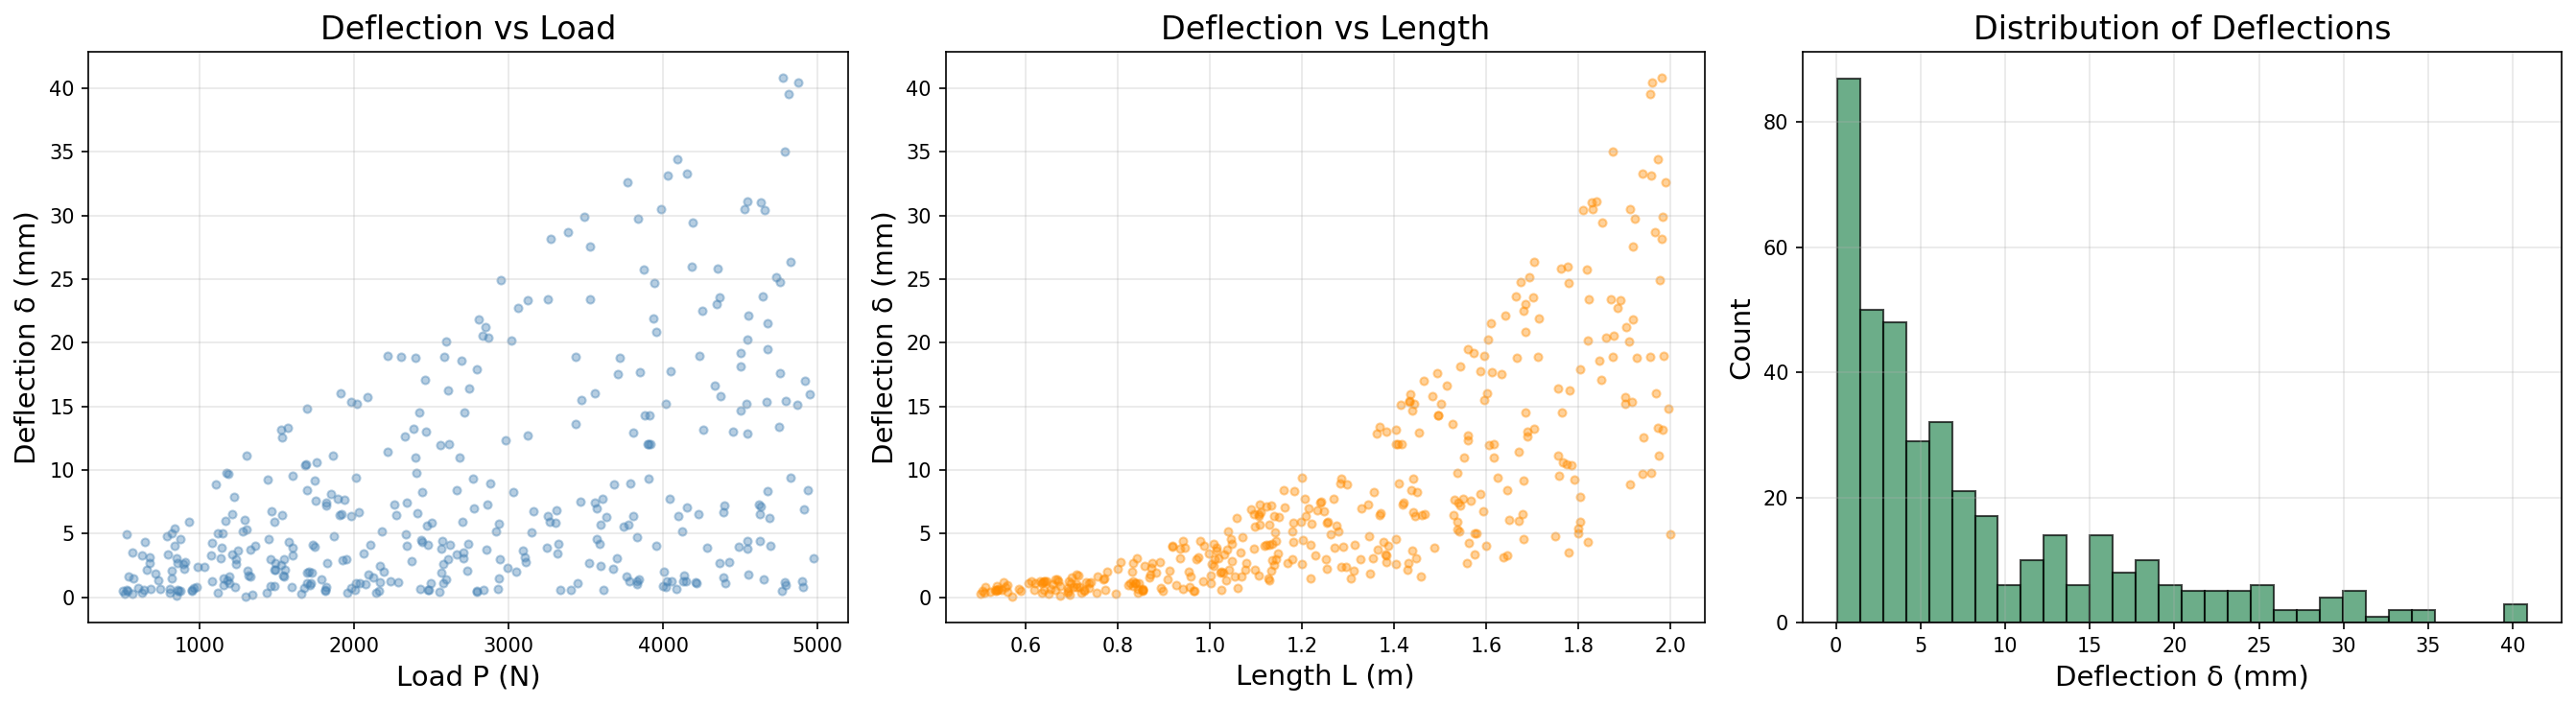


Dataset statistics:
             P_N       L_m   delta_m
count   400.0000  400.0000  400.0000
mean   2686.3087    1.2693    0.0081
std    1304.0459    0.4213    0.0085
min     504.5830    0.5003    0.0001
25%    1549.3309    0.9352    0.0017
50%    2580.6060    1.2592    0.0047
75%    3853.9405    1.6097    0.0121
max    4973.3252    1.9994    0.0408


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=150)

# 1. Deflection vs Load
axes[0].scatter(df['P_N'], df['delta_m'] * 1000, alpha=0.4, s=15, c='steelblue')
axes[0].set_xlabel('Load P (N)', fontsize=14)
axes[0].set_ylabel('Deflection δ (mm)', fontsize=14)
axes[0].set_title('Deflection vs Load', fontsize=16)
axes[0].grid(True, alpha=0.3)

# 2. Deflection vs Length
axes[1].scatter(df['L_m'], df['delta_m'] * 1000, alpha=0.4, s=15, c='darkorange')
axes[1].set_xlabel('Length L (m)', fontsize=14)
axes[1].set_ylabel('Deflection δ (mm)', fontsize=14)
axes[1].set_title('Deflection vs Length', fontsize=16)
axes[1].grid(True, alpha=0.3)

# 3. Distribution of deflections
axes[2].hist(df['delta_m'] * 1000, bins=30, color='seagreen', edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Deflection δ (mm)', fontsize=14)
axes[2].set_ylabel('Count', fontsize=14)
axes[2].set_title('Distribution of Deflections', fontsize=16)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDataset statistics:")
print(df.describe().round(4))

## 5. Train/Test Split

We split the data **70/30** into training and test sets. The model will be trained only on the training set; the test set is held out to evaluate generalization.

In [ ]:
# ── Reproducible 70/30 split ────────────────────────────────────────
rng = np.random.default_rng(42)
idx = rng.permutation(len(df))
n_tr = int(0.7 * len(df))  # 280 training, 120 test
tr_idx, te_idx = idx[:n_tr], idx[n_tr:]

# Extract raw arrays
Xtr_raw = df.loc[tr_idx, ["P_N", "L_m"]].to_numpy()   # shape (280, 2)
ytr_raw = df.loc[tr_idx, "delta_m"].to_numpy()          # shape (280,)
Xte_raw = df.loc[te_idx, ["P_N", "L_m"]].to_numpy()   # shape (120, 2)
yte_raw = df.loc[te_idx, "delta_m"].to_numpy()          # shape (120,)

print(f"Training set:  {len(ytr_raw)} samples")
print(f"Test set:      {len(yte_raw)} samples")

Training set:  280 samples
Test set:      120 samples


## 6. Data Scaling

GP-based symbolic regression works better when the input and output values are on a **similar scale** (roughly order 1). We apply simple scaling:

- Divide load $P$ by 1000 (so values are ~0.5 to 5)
- Keep length $L$ as-is (already ~0.5 to 2.0)
- Divide deflection $\delta$ by its median

The GP will discover the **functional form** (e.g., $P \cdot L^3$), and we'll use **linear scaling** to recover the correct magnitude afterward.

In [ ]:
# ── Scaling factors ─────────────────────────────────────────────────
P_scale = 1000.0                        # Divide loads by 1000
L_scale = 1.0                           # Lengths already ~O(1)
delta_scale = np.median(ytr_raw)        # Divide deflections by median

print(f"Scaling factors:")
print(f"  P_scale     = {P_scale}")
print(f"  L_scale     = {L_scale}")
print(f"  delta_scale = {delta_scale:.6e} m")

# ── Apply scaling ───────────────────────────────────────────────────
Xtr = np.column_stack([Xtr_raw[:, 0] / P_scale, Xtr_raw[:, 1] / L_scale])
Xte = np.column_stack([Xte_raw[:, 0] / P_scale, Xte_raw[:, 1] / L_scale])
ytr = ytr_raw / delta_scale
yte = yte_raw / delta_scale

print(f"\nScaled data ranges:")
print(f"  P (scaled):     [{Xtr[:, 0].min():.2f}, {Xtr[:, 0].max():.2f}]")
print(f"  L (scaled):     [{Xtr[:, 1].min():.2f}, {Xtr[:, 1].max():.2f}]")
print(f"  delta (scaled): [{ytr.min():.2f}, {ytr.max():.2f}]")

Scaling factors:
  P_scale     = 1000.0
  L_scale     = 1.0
  delta_scale = 4.696129e-03 m

Scaled data ranges:
  P (scaled):     [0.50, 4.92]
  L (scaled):     [0.50, 2.00]
  delta (scaled): [0.01, 8.70]


## 7. Custom Fitness Function: MSE with Linear Scaling

For each candidate expression $\hat{y}_{\text{raw}}$, we find the best linear fit:

$$\hat{y}_{\text{scaled}} = \alpha \cdot \hat{y}_{\text{raw}} + \beta$$

that minimizes the MSE. This way, GP is free to focus on discovering the correct **functional form** (e.g., $P \cdot L^3$) without worrying about the exact constant multiplier.

In [ ]:
def _ls_mse(y, y_pred, w):
    """
    MSE after optimal linear scaling: y ≈ alpha * y_pred + beta.

    This fitness function first finds the best alpha and beta
    via least squares, then computes the MSE of the scaled prediction.
    Lower is better.

    Args:
        y:      true target values
        y_pred: raw GP prediction (before scaling)
        w:      sample weights (not used here)
    """
    if np.std(y_pred) < 1e-10:
        # Constant prediction -- return baseline MSE
        return float(np.mean((y - np.mean(y)) ** 2))

    # Solve for alpha, beta via least squares: y ≈ alpha * y_pred + beta
    coef = np.linalg.lstsq(
        np.column_stack([y_pred, np.ones_like(y_pred)]), y, rcond=None
    )[0]
    scaled = coef[0] * y_pred + coef[1]
    return float(np.mean((y - scaled) ** 2))


# Register the custom fitness function with gplearn
ls_mse = make_fitness(function=_ls_mse, greater_is_better=False)


def linear_scaling(pred, y):
    """
    Fit the linear scaling: y ≈ alpha * pred + beta.

    Returns:
        alpha: slope of the linear scaling
        beta:  intercept of the linear scaling
    """
    if np.std(pred) < 1e-10:
        return 0.0, float(np.mean(y))
    coef = np.linalg.lstsq(
        np.column_stack([pred, np.ones_like(pred)]), y, rcond=None
    )[0]
    return float(coef[0]), float(coef[1])


print("Custom fitness function (MSE with Linear Scaling) defined.")

Custom fitness function (MSE with Linear Scaling) defined.


## 8. Converting GP Programs to SymPy Expressions

gplearn internally represents expressions as **prefix-encoded program trees**. We write a helper that converts them into readable **SymPy** symbolic expressions, so we can see exactly what formula the GP discovered.

In [ ]:
# ── Define symbolic variables ───────────────────────────────────────
P_SYM, L_SYM = sp.symbols("P L", real=True)

# Map GP variable indices to SymPy symbols
_VAR_MAP = {0: P_SYM, 1: L_SYM}

# Map GP operation names to SymPy operations
_OPS = {
    'add': lambda a, b: a + b,
    'sub': lambda a, b: a - b,
    'mul': lambda a, b: a * b,
    'div': lambda a, b: a / b,
}


def program_to_sympy(prog):
    """
    Convert a gplearn _Program to a simplified SymPy expression.

    The GP program is stored as a prefix-encoded list of nodes.
    We recursively parse this list to build a SymPy expression tree.
    """
    def _parse(nodes, idx):
        """Recursively parse prefix-encoded program list."""
        node = nodes[idx]
        if isinstance(node, _Function):
            # Function node: parse its arguments
            args = []
            next_idx = idx + 1
            for _ in range(node.arity):
                arg, next_idx = _parse(nodes, next_idx)
                args.append(arg)
            return _OPS[node.name](*args), next_idx
        elif isinstance(node, int):
            # Variable node: look up the SymPy symbol
            return _VAR_MAP[node], idx + 1
        else:
            # Constant node
            return sp.Float(float(node)), idx + 1

    result, _ = _parse(prog.program, 0)
    return sp.simplify(result)


print("SymPy conversion utility defined.")

SymPy conversion utility defined.


## 9. Setting Up the Symbolic Regressor

We configure the GP with the following key parameters:

| Parameter | Value | Purpose |
|---|---|---|
| `population_size` | 450 | Number of candidate expressions per generation |
| `generations` | 30 | Number of evolutionary iterations |
| `tournament_size` | 5 | Selection pressure (higher = more elitist) |
| `function_set` | +, −, ×, ÷ | Allowed mathematical operations |
| `parsimony_coefficient` | 0.0002 | Penalty for complex expressions (Occam's razor) |
| `p_crossover` | 0.7 | Probability of crossover (combining two parents) |
| `p_subtree_mutation` | 0.1 | Probability of replacing a random subtree |
| `p_hoist_mutation` | 0.05 | Probability of simplifying by hoisting a subtree |
| `p_point_mutation` | 0.1 | Probability of changing a single node |

The **parsimony coefficient** is important: it penalizes overly complex expressions, encouraging the GP to find **simple, interpretable** formulas.

In [ ]:
# ── Parsimony coefficient ───────────────────────────────────────────
# This penalizes expression complexity: fitness = MSE + PARSIMONY * length
PARSIMONY = 0.0002

# ── Configure the Symbolic Regressor ─────────────────────────────────
est_gp = SymbolicRegressor(
    population_size=450,           # 450 candidate expressions per generation
    generations=30,                # Evolve for 30 generations
    tournament_size=5,             # Tournament selection with size 5
    function_set=['add', 'sub', 'mul', 'div'],  # Basic arithmetic only
    metric=ls_mse,                 # Custom fitness: MSE with linear scaling
    parsimony_coefficient=PARSIMONY,  # Penalize complex expressions
    p_crossover=0.7,               # 70% crossover
    p_subtree_mutation=0.1,        # 10% subtree mutation
    p_hoist_mutation=0.05,         # 5% hoist mutation
    p_point_mutation=0.1,          # 10% point mutation
    max_samples=1.0,               # Use all training samples
    verbose=1,                     # Print progress
    random_state=7,                # Reproducibility
    n_jobs=1,                      # Single-threaded for reproducibility
    init_depth=(2, 6),             # Initial tree depth range
    init_method='half and half',   # Mix of grow and full initialization
    low_memory=False,              # Keep all generations for analysis
)

print("Symbolic Regressor configured.")
print(f"  Population: {est_gp.population_size}")
print(f"  Generations: {est_gp.generations}")
print(f"  Function set: {est_gp.function_set}")
print(f"  Parsimony: {PARSIMONY}")

Symbolic Regressor configured.
  Population: 450
  Generations: 30
  Function set: ['add', 'sub', 'mul', 'div']
  Parsimony: 0.0002


## 10. Running the Evolutionary Search

Now we let the GP evolve!

The GP will:
1. Create an initial random population of 450 expressions
2. Evaluate each expression's fitness (MSE with linear scaling + parsimony penalty)
3. Select the best via tournament selection
4. Apply crossover and mutation to create new offspring
5. Repeat for 30 generations

In [ ]:
print("Running GP Symbolic Regression...")
print("=" * 80)

# Fit the model on scaled training data
est_gp.fit(Xtr, ytr)

print("=" * 80)
print("\nEvolution complete!")

Running GP Symbolic Regression...
    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    37.24          2.36493       43        0.0833466              N/A     25.23s
   1    27.75          1.54945        7       0.00109882              N/A     20.01s
   2    29.34          1.09238       11       0.00109882              N/A     12.92s
   3    30.37         0.889373       11       0.00109882              N/A     13.27s
   4    30.85         0.791023       11       0.00109882              N/A     12.78s
   5    29.64         0.784285       11       0.00109882              N/A     12.28s
   6    29.47         0.705783       57       0.00109141              N/A     10.86s
   7    31.84          0.61201       57       0.00109139              N/A     11.88s
   8    31.40         0.543305       61  

## 11. Analyzing the Best Expression Per Generation

Let's look at how the best expression evolved over generations. We track:
- The **fitness** (MSE + parsimony penalty) of the best program at each generation
- The **symbolic form** of that program
- Its **size** (number of nodes in the expression tree)

In [ ]:
print("Per-generation best (MSE + parsimony penalty):")
print("-" * 80)

best_fit_so_far = float("inf")
for gen_idx, gen_programs in enumerate(est_gp._programs):
    # Filter out None entries (removed programs)
    valid = [p for p in gen_programs if p is not None]
    if not valid:
        continue

    # Find the best program in this generation
    best_gen = min(valid, key=lambda p: p.raw_fitness_)
    fit_val = best_gen.raw_fitness_ + PARSIMONY * best_gen.length_

    if fit_val < best_fit_so_far:
        best_fit_so_far = fit_val

    # Convert to SymPy for readable output
    try:
        expr = program_to_sympy(best_gen)
    except Exception:
        expr = str(best_gen)

    print(f"Gen {gen_idx:3d} | Fitness: {best_fit_so_far:.6f} | "
          f"Size: {best_gen.length_:3d} nodes | Form: {expr}")

print("-" * 80)

Per-generation best (MSE + parsimony penalty):
--------------------------------------------------------------------------------
Gen   0 | Fitness: 0.091947 | Size:  43 nodes | Form: 0.582914342222076*L**2*P + 0.786714387930835*L**2 + 0.0539684723321837*L*P - 0.0026447013482847*P
Gen   1 | Fitness: 0.002499 | Size:   7 nodes | Form: L**3*P
Gen   2 | Fitness: 0.002499 | Size:  11 nodes | Form: 0.769285722413592*L**3*P
Gen   3 | Fitness: 0.002499 | Size:  11 nodes | Form: 0.769285722413592*L**3*P
Gen   4 | Fitness: 0.002499 | Size:  11 nodes | Form: 0.769285722413592*L**3*P
Gen   5 | Fitness: 0.002499 | Size:  11 nodes | Form: 0.769285722413592*L**3*P
Gen   6 | Fitness: 0.002499 | Size:  57 nodes | Form: L*(81.9030700202024*L**2*P - 0.597983061816274*L**2*(L - 0.10342098533851)/(P*(-40.9515350101012*L*(P + 0.870348554468094) - 0.906443954422217*(L + P)/L)) + L) + P
Gen   7 | Fitness: 0.002499 | Size:  57 nodes | Form: L*(81.9030700202024*L**2*P - 1.40816362793385*L**2*(P - 0.2304645476824

## 12. Extracting the Overall Best Program

Now we find the single best program across **all** generations and apply linear scaling to get the final prediction.

In [ ]:
# ── Find the overall best program ───────────────────────────────────
overall_best = None
overall_best_fitness = float("inf")

for gen_programs in est_gp._programs:
    for p in gen_programs:
        if p is not None:
            f = p.raw_fitness_ + PARSIMONY * p.length_
            if f < overall_best_fitness:
                overall_best_fitness = f
                overall_best = p

best_program = overall_best
discovered_form = program_to_sympy(best_program)

print(f"Best discovered expression (dimensionless):")
print(f"  {discovered_form}")
print(f"\nExpression tree size: {best_program.length_} nodes")
print(f"Raw fitness: {best_program.raw_fitness_:.6f}")
print(f"Total fitness (with parsimony): {overall_best_fitness:.6f}")

Best discovered expression (dimensionless):
  L**3*P

Expression tree size: 7 nodes
Raw fitness: 0.001099
Total fitness (with parsimony): 0.002499


In [ ]:
# ── Apply linear scaling ────────────────────────────────────────────
# Get raw predictions from the best program
raw_pred_tr = best_program.execute(Xtr)   # Raw GP output on training data
raw_pred_te = best_program.execute(Xte)   # Raw GP output on test data

# Fit linear scaling on training data: y ≈ alpha * raw_pred + beta
alpha, beta = linear_scaling(raw_pred_tr, ytr)

# Apply scaling to get final predictions
yhat_tr = alpha * raw_pred_tr + beta    # Scaled training predictions
yhat_te = alpha * raw_pred_te + beta    # Scaled test predictions

print(f"Linear scaling coefficients:")
print(f"  alpha = {alpha:.6e}")
print(f"  beta  = {beta:.6e}")
print(f"\nFinal model: y = {alpha:.4e} × ({discovered_form}) + {beta:.4e}")

Linear scaling coefficients:
  alpha = 2.340710e-01
  beta  = 6.001732e-03

Final model: y = 2.3407e-01 × (L**3*P) + 6.0017e-03


## 13. Evaluation Metrics

We evaluate the model using:
- **MSE** (Mean Squared Error): average squared prediction error
- **R²** (Coefficient of Determination): 1 means perfect prediction, 0 means no better than the mean

In [ ]:
# ── Compute metrics ─────────────────────────────────────────────────
mse_tr = float(np.mean((ytr - yhat_tr) ** 2))
r2_tr = 1.0 - np.sum((ytr - yhat_tr) ** 2) / np.sum((ytr - np.mean(ytr)) ** 2)

mse_te = float(np.mean((yte - yhat_te) ** 2))
r2_te = 1.0 - np.sum((yte - yhat_te) ** 2) / np.sum((yte - np.mean(yte)) ** 2)

print("=" * 60)
print("FINAL RESULTS")
print("=" * 60)
print(f"\nDiscovered Functional Form: {discovered_form}")
print(f"Linear Scaling: alpha = {alpha:.6e}, beta = {beta:.6e}")
print(f"\n{'Set':<12} {'MSE':>10} {'R²':>10}")
print("-" * 35)
print(f"{'Training':<12} {mse_tr:>10.6f} {r2_tr:>10.4f}")
print(f"{'Test':<12} {mse_te:>10.6f} {r2_te:>10.4f}")
print("-" * 35)

if r2_te > 0.99:
    print("\n✓ Excellent fit! The GP likely rediscovered the true functional form.")
elif r2_te > 0.95:
    print("\n✓ Good fit. The discovered form captures most of the variance.")
else:
    print("\n⚠ Moderate fit. Try increasing generations or population size.")

FINAL RESULTS

Discovered Functional Form: L**3*P
Linear Scaling: alpha = 2.340710e-01, beta = 6.001732e-03

Set                 MSE         R²
-----------------------------------
Training       0.001099     0.9997
Test           0.001266     0.9996
-----------------------------------

✓ Excellent fit! The GP likely rediscovered the true functional form.


## 14. Parity Plots (Predicted vs Measured)

A **parity plot** shows predicted values on the y-axis vs measured values on the x-axis. Perfect predictions fall on the diagonal line $\hat{y} = y$.

We plot both training and test sets side by side. Close clustering around the diagonal indicates a good model.

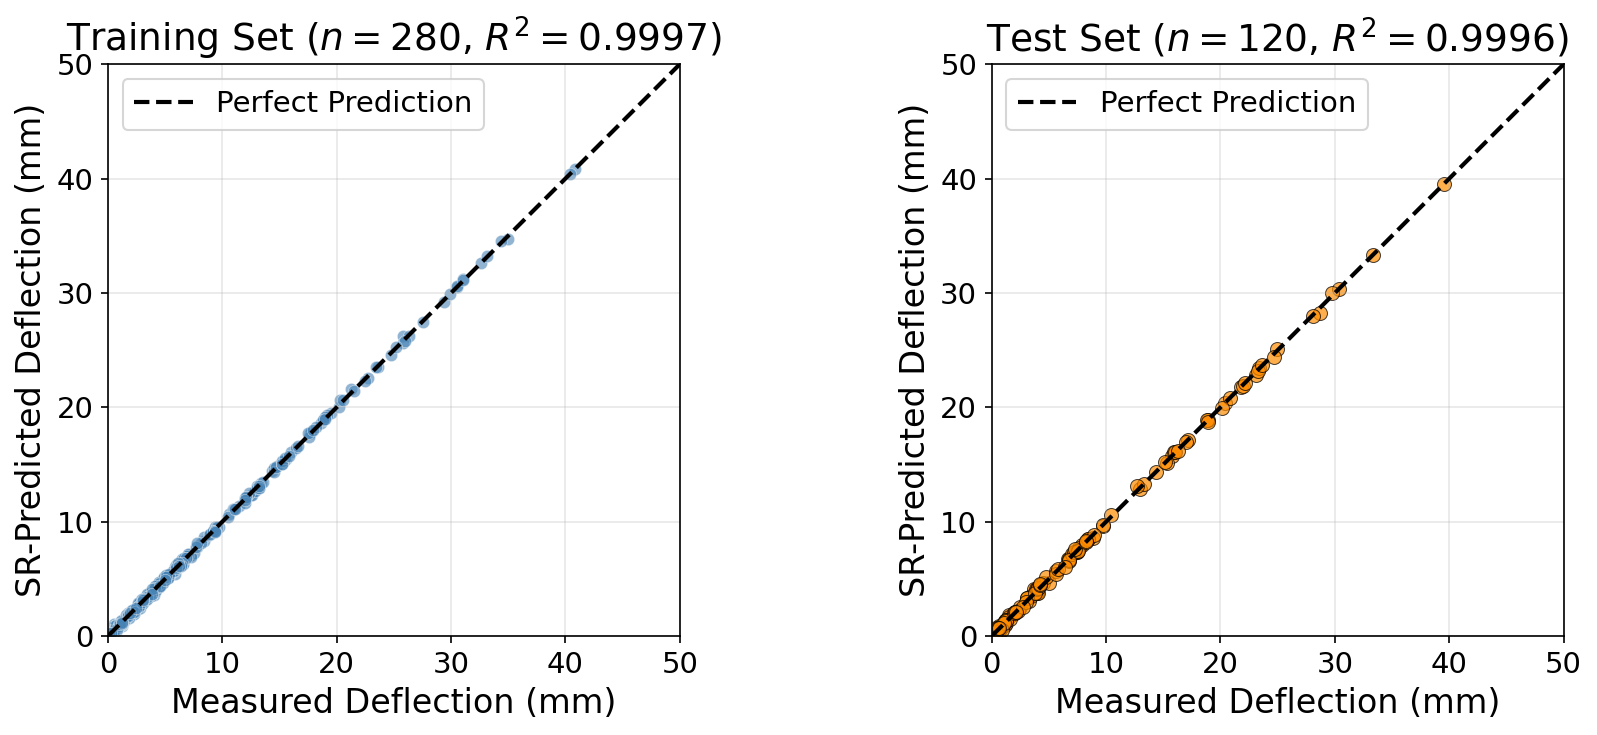

In [ ]:
# Convert back to physical units (mm) for interpretability
ytr_mm = 1000.0 * ytr_raw                    # Measured deflection (mm)
yhat_tr_mm = 1000.0 * (delta_scale * yhat_tr) # Predicted deflection (mm)
yte_mm = 1000.0 * yte_raw
yhat_te_mm = 1000.0 * (delta_scale * yhat_te)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)
lims = [0, 50]  # Axis limits in mm

# ── Training set parity plot ────────────────────────────────────────
ax1 = axes[0]
ax1.scatter(ytr_mm, yhat_tr_mm, alpha=0.6, s=35, c='steelblue',
            edgecolors='white', linewidths=0.3)
ax1.plot(lims, lims, "k--", linewidth=2, label="Perfect Prediction")
ax1.set_xlim(lims)
ax1.set_ylim(lims)
ax1.set_xlabel("Measured Deflection (mm)", fontsize=16)
ax1.set_ylabel("SR-Predicted Deflection (mm)", fontsize=16)
ax1.set_title(f"Training Set ($n={len(ytr)}$, $R^2={r2_tr:.4f}$)", fontsize=18)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=14, loc='upper left')

# ── Test set parity plot ────────────────────────────────────────────
ax2 = axes[1]
ax2.scatter(yte_mm, yhat_te_mm, alpha=0.7, s=45, c='darkorange',
            edgecolors='black', linewidths=0.5)
ax2.plot(lims, lims, "k--", linewidth=2, label="Perfect Prediction")
ax2.set_xlim(lims)
ax2.set_ylim(lims)
ax2.set_xlabel("Measured Deflection (mm)", fontsize=16)
ax2.set_ylabel("SR-Predicted Deflection (mm)", fontsize=16)
ax2.set_title(f"Test Set ($n={len(yte)}$, $R^2={r2_te:.4f}$)", fontsize=18)
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=14, loc='upper left')

plt.tight_layout()
plt.show()

## 15. Fitness Convergence

Let's plot how the **best fitness** (MSE + parsimony penalty) improved over generations. A decreasing trend indicates the GP is successfully evolving better expressions.

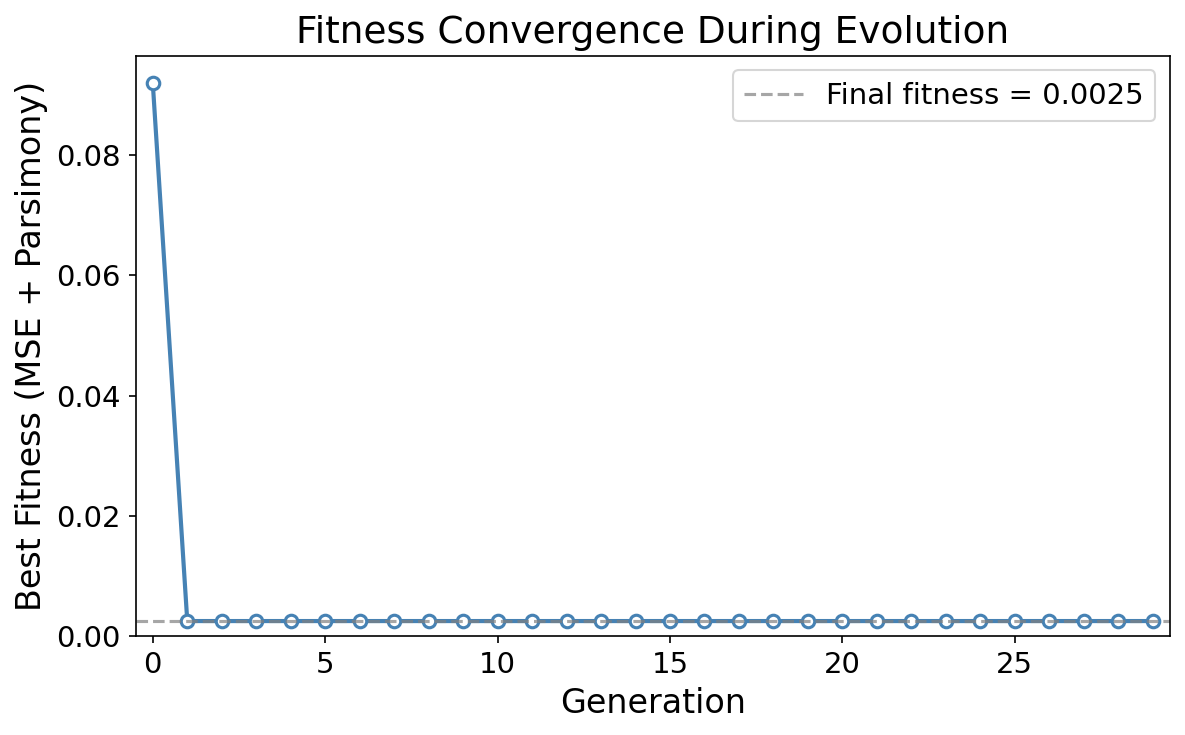

Starting fitness (gen 0): 0.091947
Final fitness (gen 29): 0.002499
Improvement: 97.3%


In [ ]:
# ── Compute cumulative-minimum fitness per generation ───────────────
best_mse = np.array(est_gp.run_details_['best_fitness'])
best_len = np.array(est_gp.run_details_['best_length'])
hist = best_mse + PARSIMONY * best_len      # fitness = MSE + parsimony * length
hist_cummin = np.minimum.accumulate(hist)    # Running minimum

# ── Plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
generations_arr = np.arange(len(hist_cummin))

ax.plot(generations_arr, hist_cummin, 'o-', color='steelblue', linewidth=2,
        markersize=6, markerfacecolor='white', markeredgewidth=1.5)
ax.set_xlabel("Generation", fontsize=16)
ax.set_ylabel("Best Fitness (MSE + Parsimony)", fontsize=16)
ax.set_title("Fitness Convergence During Evolution", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlim(-0.5, len(hist_cummin) - 0.5)
ax.set_ylim(0, max(hist_cummin) * 1.05)
ax.axhline(y=hist_cummin[-1], color='gray', linestyle='--', alpha=0.7,
           label=f'Final fitness = {hist_cummin[-1]:.4f}')
ax.legend(fontsize=14, loc='upper right')

plt.tight_layout()
plt.show()

print(f"Starting fitness (gen 0): {hist_cummin[0]:.6f}")
print(f"Final fitness (gen {len(hist_cummin)-1}): {hist_cummin[-1]:.6f}")
print(f"Improvement: {(1 - hist_cummin[-1]/hist_cummin[0])*100:.1f}%")